# Tutorial: Milestone 1 - Transformer Sanity Check (DistilBERT)

Audience:
- You've already run Milestone 0 (`notebooks/milestone0_text_only.ipynb`) and understand the load -> split -> train -> evaluate loop with TF-IDF + Logistic Regression.

Prerequisites:
- Milestone 0 concepts: sample, feature, label, train/val/test, accuracy, macro-F1, confusion matrix.
- The `mmi` conda environment with `torch`, `transformers`, `datasets`, and `accelerate` installed (heavier than Milestone 0 — a few hundred MB of libraries plus a one-time ~300MB DistilBERT download).

Learning goals:
- By the end, you can explain what "fine-tuning a pretrained transformer" means, run it on the same tiny dataset as Milestone 0, and compare its results head-to-head against the sklearn baseline.

**Why this notebook exists:** before pointing this pipeline at the real MIntRec dataset (the actual Milestone 1 goal per `CLAUDE.md`), we sanity-check the transformer code path on the small bundled dataset — same idea as "run on 10 samples before the real training run." If something's broken, we find out in 15 seconds, not after a long download and training run on real data.


## Outline

1. Setup — imports, paths, and why this needs heavier libraries than Milestone 0
2. Step 1-2 — Load and split the same data as Milestone 0 (for a fair comparison)
3. Step 3 — Fine-tune a pretrained transformer (DistilBERT)
4. Step 4 — Evaluate, and compare head-to-head against the Milestone 0 baseline
5. Look at the mistakes
6. Exercises
7. Pitfalls and extensions


## Setup

New terms this notebook introduces:
- **pretrained model**: a neural network that already learned general language patterns from a huge amount of text before we ever touch it. We're not starting from scratch.
- **fine-tuning**: continuing to train a pretrained model on *our* small labeled dataset, so it specializes on our 8 intents while keeping the general language understanding it already has.
- **tokenizer**: chops text into sub-word pieces ("tokens") the model understands, and converts them to numbers — the transformer's equivalent of `TfidfVectorizer`, but it also captures word order and context.
- **epoch**: one full pass through the training data. We fine-tune for 5 epochs (5 full passes over the 61 training sentences).

We use `distilbert-base-uncased` — a *distilled* (compressed, faster) version of BERT — because it's small enough to fine-tune on a laptop CPU in seconds, matching the CLAUDE.md preference for lightweight models while prototyping.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_PATH = PROJECT_ROOT / "data" / "sample_intents.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
DATA_PATH


WindowsPath('c:/Users/dbest/Downloads/multimodal-intent-inference/multimodal-intent-inference/data/sample_intents.csv')

## Step 1-2 - Load and split the same data as Milestone 0

Same file, same split settings (`test_size`, `random_state`, `stratify`) as the Milestone 0 notebook, so the
comparison at the end is apples-to-apples: both models are trained on the exact same 61 sentences and
judged on the exact same 20 test sentences.


In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} samples from {DATA_PATH.name}")

train_val, test = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df["intent"]
)
train, val = train_test_split(
    train_val, test_size=0.1875, random_state=42, stratify=train_val["intent"]
)

print(f"train: {len(train)} samples  (model learns from these)")
print(f"val:   {len(val)} samples  (used to monitor fine-tuning below)")
print(f"test:  {len(test)} samples  (final honest judgement)")


Loaded 96 samples from sample_intents.csv
train: 61 samples  (model learns from these)
val:   15 samples  (used to monitor fine-tuning below)
test:  20 samples  (final honest judgement)


## Step 3 - Fine-tune a pretrained transformer (DistilBERT)

1. `label2id` / `id2label` — models work with integer class IDs internally, not strings like `"agree"`, so we
   need a lookup table in both directions.
2. `AutoTokenizer.from_pretrained(...)` downloads (once, cached after) and loads DistilBERT's tokenizer.
3. `to_dataset(...)` converts our pandas DataFrame into a Hugging Face `Dataset` and tokenizes every sentence.
4. `AutoModelForSequenceClassification.from_pretrained(...)` loads DistilBERT with a fresh, randomly
   initialized classification head sized for our 8 intents — the "MISSING" keys you'll see printed below are
   expected: they're that new head, which fine-tuning is about to train.
5. `Trainer` runs the actual fine-tuning loop and prints the training loss shrinking over time — that's the
   model's error going down as it learns.


In [3]:
labels = sorted(train["intent"].unique())
label2id = {name: i for i, name in enumerate(labels)}
id2label = {i: name for name, i in label2id.items()}

ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(ckpt)


def to_dataset(frame):
    ds = Dataset.from_dict(
        {
            "text": frame["text"].tolist(),
            "label": [label2id[x] for x in frame["intent"]],
        }
    )
    return ds.map(
        lambda b: tokenizer(b["text"], truncation=True, padding="max_length", max_length=32),
        batched=True,
    )


train_ds, val_ds = to_dataset(train), to_dataset(val)

model = AutoModelForSequenceClassification.from_pretrained(
    ckpt, num_labels=len(labels), id2label=id2label, label2id=label2id
)
print("Model loaded. The MISSING classifier/pre_classifier weights above are the new head we're about to train.")


Map:   0%|          | 0/61 [00:00<?, ? examples/s]

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded. The MISSING classifier/pre_classifier weights above are the new head we're about to train.


In [4]:
args = TrainingArguments(
    output_dir=str(PROJECT_ROOT / "models" / "distilbert_intent"),
    per_device_train_batch_size=8,
    num_train_epochs=5,
    logging_steps=5,
    report_to="none",
)


def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    return {"macro_f1": f1_score(pred.label_ids, preds, average="macro")}


trainer = Trainer(
    model=model, args=args, train_dataset=train_ds,
    eval_dataset=val_ds, compute_metrics=compute_metrics,
)
trainer.train()
print("Fine-tuning done. Watch the loss numbers above shrink across steps -- that's the model learning.")


C:\Users\dbest\anaconda3\envs\mmi\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
5,2.073205
10,2.008543
15,1.824972
20,1.646863
25,1.476602
30,1.337149
35,1.286696
40,1.221563


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuning done. Watch the loss numbers above shrink across steps -- that's the model learning.


## Step 4 - Evaluate, and compare against Milestone 0

Same metrics as Milestone 0: **accuracy** (share of exactly-right predictions) and **macro-F1** (F1 averaged
equally across intents, so rare classes aren't ignored). We predict on the *same* 20 test sentences Milestone
0 used, so the two scores are directly comparable.


In [5]:
def predict(texts):
    enc = tokenizer(list(texts), truncation=True, padding=True, max_length=32, return_tensors="pt")
    with torch.no_grad():
        logits = model(**enc).logits
    ids = logits.argmax(dim=1).tolist()
    return [id2label[i] for i in ids]


preds = predict(test["text"])
truth = test["intent"].tolist()

acc = accuracy_score(truth, preds)
macro_f1 = f1_score(truth, preds, average="macro")
print(f"Accuracy : {acc:.3f}   (share of predictions that were exactly right)")
print(f"Macro-F1 : {macro_f1:.3f}   (fairer average across all intents)")


Accuracy : 0.800   (share of predictions that were exactly right)
Macro-F1 : 0.740   (fairer average across all intents)


In [6]:
print(classification_report(truth, preds, zero_division=0))


              precision    recall  f1-score   support

       agree       0.00      0.00      0.00         2
   apologize       1.00      1.00      1.00         2
    complain       1.00      0.33      0.50         3
    disagree       0.60      1.00      0.75         3
    greeting       1.00      1.00      1.00         3
    reassure       0.50      1.00      0.67         2
     request       1.00      1.00      1.00         3
       thank       1.00      1.00      1.00         2

    accuracy                           0.80        20
   macro avg       0.76      0.79      0.74        20
weighted avg       0.79      0.80      0.75        20



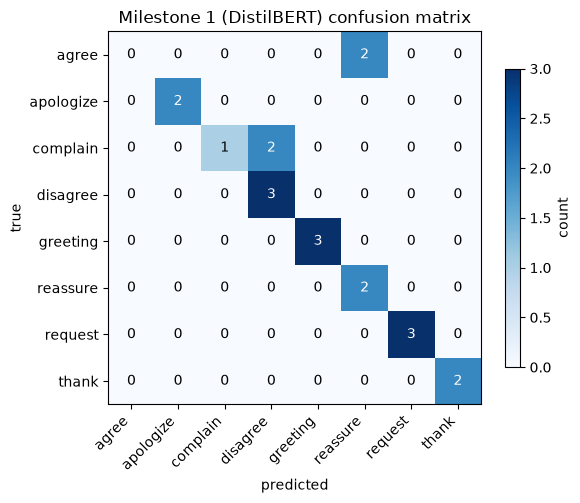

In [7]:
labels_sorted = sorted(test["intent"].unique())
cm = confusion_matrix(truth, preds, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_sorted)), labels_sorted, rotation=45, ha="right")
ax.set_yticks(range(len(labels_sorted)), labels_sorted)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Milestone 1 (DistilBERT) confusion matrix")
for i in range(len(labels_sorted)):
    for j in range(len(labels_sorted)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="count")
fig.tight_layout()
plt.show()


### Head-to-head vs. the Milestone 0 sklearn baseline

Same data, same split, same test sentences — only the model differs.


In [8]:
# Milestone 0 baseline numbers, copied from notebooks/milestone0_text_only.ipynb
# (TF-IDF + Logistic Regression, same train/test split).
baseline = {"model": "TF-IDF + Logistic Regression (M0)", "accuracy": 0.550, "macro_f1": 0.521}
transformer_result = {"model": "DistilBERT fine-tuned (M1)", "accuracy": acc, "macro_f1": macro_f1}

pd.DataFrame([baseline, transformer_result]).set_index("model")


,accuracy,macro_f1
model,,
TF-IDF + Logistic Regression (M0),0.55,0.521000
DistilBERT fine-tuned (M1),0.80,0.739583


## Look at the mistakes

Saved to its own file (`milestone0_predictions_transformer.csv`) so it doesn't overwrite the sklearn
baseline's predictions — the two models' outputs now live side by side in `results/`.


In [9]:
results_df = pd.DataFrame({"text": test["text"], "true": truth, "predicted": preds})

RESULTS_DIR.mkdir(exist_ok=True)
out_path = RESULTS_DIR / "milestone0_predictions_transformer.csv"
results_df.to_csv(out_path, index=False)
print(f"Saved every test prediction to {out_path.relative_to(PROJECT_ROOT)}")

mistakes = results_df[results_df["true"] != results_df["predicted"]]
print(f"\n{len(mistakes)} of {len(results_df)} test sentences were misclassified:")
mistakes


Saved every test prediction to results\milestone0_predictions_transformer.csv

4 of 20 test sentences were misclassified:


,text,true,predicted
42,"Agreed, let's go with your idea.",agree,reassure
60,This is completely unacceptable.,complain,disagree
45,"Fair enough, I'll go along with it.",agree,reassure
68,"Honestly, this is not good enough.",complain,disagree


## Exercises

1. **Predict before running:** the training args above use `num_train_epochs=5`. Change it to `num_train_epochs=1`
   in the Step 3 training-args cell and rerun Steps 3-4. Do you expect accuracy to go up, down, or barely change
   with only one pass over 61 sentences? Run it and check.
2. Compare the confusion matrix here to Milestone 0's. Which intents did the transformer fix that sklearn got
   wrong? Which intent got *worse*? (Hint: check `complain`.)


## Pitfalls and extensions

**Common mistake:** treating one run's score as gospel. With only 61 training and 20 test sentences, a single
fine-tuning run's accuracy can swing several points from one random seed to the next — the same instability we
saw in Milestone 0's exercises. Don't conclude "DistilBERT is definitely 20 points better" from one run; treat
it as "DistilBERT looks meaningfully better on this small sample, worth confirming on more data."

**Compute note:** this fine-tuned the *entire* model (all of DistilBERT's weights, not just the new
classification head). CLAUDE.md's Hard Rules prefer frozen encoders while prototyping — as an extension, try
freezing the base model (`for p in model.distilbert.parameters(): p.requires_grad = False`) before training
and see how much faster it runs and how much accuracy changes.

**Extension (the real Milestone 1 goal):** this notebook only proves the transformer code path works. The
actual next step is pointing this same pipeline at the real **MIntRec** dataset (`thuiar/MIntRec`, cloned
separately) instead of the 96-sentence bundled sample — a bigger step involving a real download, worth
planning as its own task.
